# Hari 5-7 — EDA Mendalam & Konsolidasi Minggu 1

**Recap keputusan dari Hari 4:**
- Periode sebelum vaksinasi (sebelum Jan 2021): **diisi angka 0**
- Fitur vaksinasi yang dipakai: **persentase populasi tervaksin** (bukan angka kumulatif mentah)
- Ada catatan **"lonjakan aneh"** di grafik yang perlu diselidiki lebih lanjut

Tiga bagian di notebook ini: **Hari 5** (statistik deskriptif + terapkan keputusan di atas), **Hari 6** (dekomposisi time-series + deteksi outlier untuk menyelidiki "lonjakan aneh"), **Hari 7** (konsolidasi & penutupan Minggu 1).

---
# BAGIAN A — Hari 5: Statistik Deskriptif & Menerapkan Keputusan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Muat ulang & bangun kembali data gabungan (sama seperti Hari 3-4)
vaksin = pd.read_csv("vaksinasi.csv")
kasus = pd.read_csv("harian.csv")

vaksin["Date"] = pd.to_datetime(vaksin["key_as_string"], utc=True)
kasus["Date"] = pd.to_datetime(kasus["key_as_string"], utc=True)

vaksin = vaksin.sort_values("Date").set_index("Date")
kasus = kasus.sort_values("Date").set_index("Date")

kasus_mingguan = kasus["jumlah_positif"].resample("W").sum().rename("kasus_baru_mingguan")
vaksin_mingguan = vaksin["jumlah_jumlah_vaksinasi_1_kum"].resample("W").last().rename("vaksin_dosis1_kumulatif")

gabungan = pd.concat([kasus_mingguan, vaksin_mingguan], axis=1)
print(f"Data gabungan awal: {gabungan.shape[0]} minggu")

Data gabungan awal: 147 minggu


## Menerapkan Keputusan #1: Isi Periode Sebelum Vaksinasi dengan 0

Sesuai refleksi Hari 4 — periode sebelum Januari 2021 memang belum ada program vaksinasi, jadi mengisi 0 lebih masuk akal daripada memotong data (kita tetap butuh histori kasus dari Maret 2020 untuk model forecasting).

In [2]:
gabungan["vaksin_dosis1_kumulatif"] = gabungan["vaksin_dosis1_kumulatif"].fillna(0)
print("Missing values setelah fillna(0):")
print(gabungan.isnull().sum())

Missing values setelah fillna(0):
kasus_baru_mingguan        0
vaksin_dosis1_kumulatif    0
dtype: int64


## Menerapkan Keputusan #2: Ubah ke Persentase Populasi Tervaksin

Kita pakai angka populasi Indonesia dari sensus 2020 (~270,2 juta) sebagai penyebut. **Catatan penting:** ini angka statis (tidak memperhitungkan pertumbuhan penduduk tahun ke tahun) — cukup akurat untuk proyek belajar ini, tapi bukan angka resmi real-time.

In [3]:
POPULASI_INDONESIA = 270_203_917  # Sensus BPS 2020, angka statis (simplifikasi)

gabungan["vaksin_persen"] = (gabungan["vaksin_dosis1_kumulatif"] / POPULASI_INDONESIA) * 100
gabungan = gabungan.drop(columns=["vaksin_dosis1_kumulatif"])  # ganti dengan versi persentase

print(gabungan[["kasus_baru_mingguan", "vaksin_persen"]].tail(10))

                           kasus_baru_mingguan  vaksin_persen
Date                                                         
2022-10-23 00:00:00+00:00                14093      75.902626
2022-10-30 00:00:00+00:00                19661      75.919834
2022-11-06 00:00:00+00:00                30670      75.938977
2022-11-13 00:00:00+00:00                40212      75.960700
2022-11-20 00:00:00+00:00                46863      75.984620
2022-11-27 00:00:00+00:00                41877      76.020068
2022-12-04 00:00:00+00:00                29959      75.398628
2022-12-11 00:00:00+00:00                18587      75.434557
2022-12-18 00:00:00+00:00                10807      75.464296
2022-12-25 00:00:00+00:00                 6527      75.489253


## Statistik Deskriptif Lengkap

In [4]:
print(gabungan.describe())
print("\nSkewness (kemencengan distribusi):")
print(gabungan["kasus_baru_mingguan"].skew())
# Skewness > 1 artinya distribusi menceng kanan (banyak minggu kasus rendah, sedikit minggu lonjakan tinggi)
# Ini WAJAR untuk data pandemi — bukan berarti ada kesalahan data

       kasus_baru_mingguan  vaksin_persen
count           147.000000     147.000000
mean          45687.918367      32.487534
std           72398.029301      33.222648
min               6.000000       0.000000
25%            6958.500000       0.000000
50%           23648.000000      17.571236
75%           41175.500000      73.219747
max          389727.000000      76.020068

Skewness (kemencengan distribusi):
2.9064372358558797


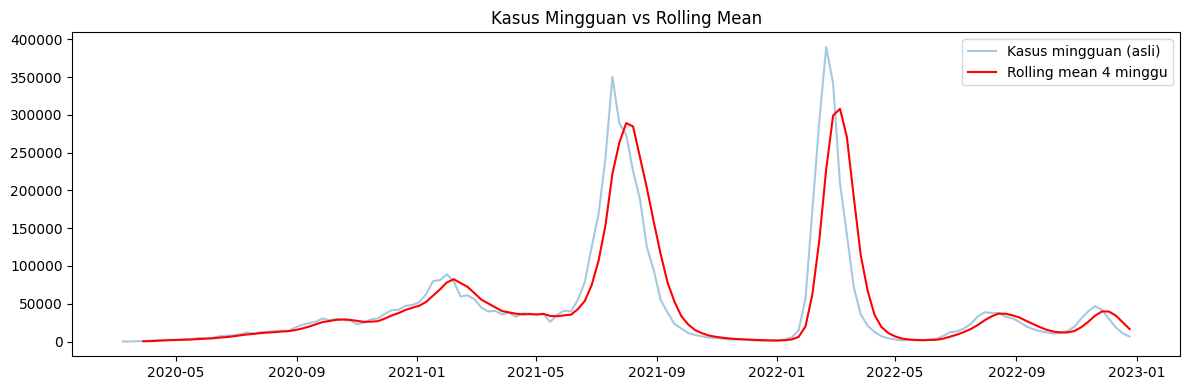

In [5]:
# Rolling statistics — melihat tren jangka menengah (4 minggu, ~1 bulan)
gabungan["rolling_mean_4w"] = gabungan["kasus_baru_mingguan"].rolling(4).mean()
gabungan["rolling_std_4w"] = gabungan["kasus_baru_mingguan"].rolling(4).std()

plt.figure(figsize=(12, 4))
plt.plot(gabungan.index, gabungan["kasus_baru_mingguan"], alpha=0.4, label="Kasus mingguan (asli)")
plt.plot(gabungan.index, gabungan["rolling_mean_4w"], color="red", label="Rolling mean 4 minggu")
plt.legend()
plt.title("Kasus Mingguan vs Rolling Mean")
plt.tight_layout()
plt.show()

In [6]:
# Growth rate mingguan (% perubahan dari minggu sebelumnya)
gabungan["growth_rate"] = gabungan["kasus_baru_mingguan"].pct_change() * 100

print("Statistik growth rate mingguan (%):")
print(gabungan["growth_rate"].describe())
print(f"\nJumlah minggu dengan lonjakan >100% dari minggu sebelumnya: {(gabungan['growth_rate'] > 100).sum()}")
print(f"Jumlah minggu dengan penurunan >50% dari minggu sebelumnya: {(gabungan['growth_rate'] < -50).sum()}")

Statistik growth rate mingguan (%):
count     146.000000
mean       22.271279
std       152.129177
min       -51.868512
25%       -16.612670
50%         1.355098
75%        22.095612
max      1750.000000
Name: growth_rate, dtype: float64

Jumlah minggu dengan lonjakan >100% dari minggu sebelumnya: 7
Jumlah minggu dengan penurunan >50% dari minggu sebelumnya: 1


---
# BAGIAN B — Hari 6: Dekomposisi Time-Series & Deteksi Outlier

Sekarang kita selidiki "lonjakan aneh" yang kamu catat di Hari 4, dengan cara yang lebih sistematis daripada sekadar melihat grafik.

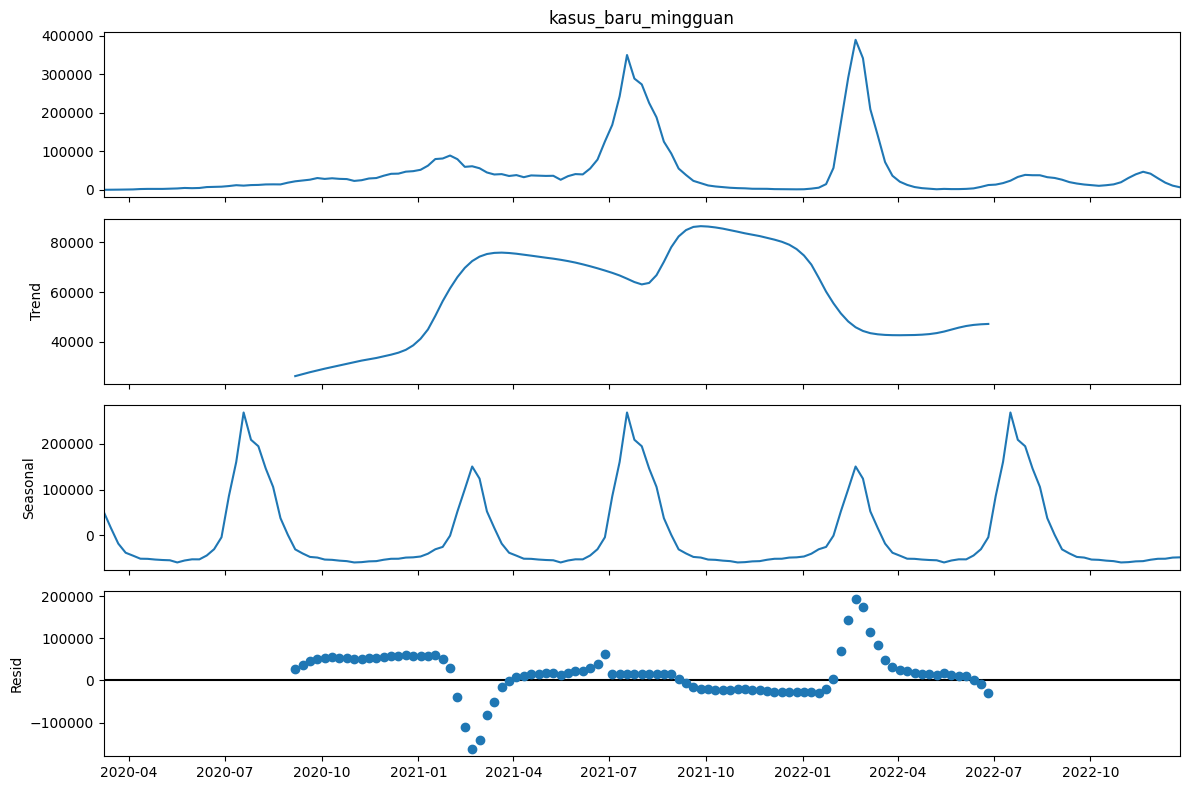

In [7]:
# statsmodels biasanya sudah terinstall di Colab. Jika belum, uncomment baris di bawah:
# !pip install statsmodels --quiet

from statsmodels.tsa.seasonal import seasonal_decompose

# Perlu data tanpa NaN. Interpolasi kecil untuk titik yang masih kosong (jika ada).
series = gabungan["kasus_baru_mingguan"].interpolate()

# period=52 karena data mingguan, pola tahunan = 52 minggu
decomposition = seasonal_decompose(series, model="additive", period=52)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

Perhatikan komponen **residual** (panel paling bawah) — ini adalah bagian data yang *tidak* dijelaskan oleh tren atau pola musiman. Titik-titik residual yang jauh dari nol itulah kandidat "lonjakan aneh" yang kamu catat. Kita deteksi secara sistematis di bawah.

In [8]:
residual = decomposition.resid.dropna()

# Deteksi outlier dengan metode IQR pada residual
Q1 = residual.quantile(0.25)
Q3 = residual.quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outlier_weeks = residual[(residual < batas_bawah) | (residual > batas_atas)]
print(f"Ditemukan {len(outlier_weeks)} minggu terindikasi outlier dari {len(residual)} minggu:")
print(outlier_weeks)

Ditemukan 4 minggu terindikasi outlier dari 95 minggu:
Date
2021-02-21 00:00:00+00:00   -161817.227163
2021-02-28 00:00:00+00:00   -142148.881010
2022-02-20 00:00:00+00:00    193419.051683
2022-02-27 00:00:00+00:00    173750.705529
Name: resid, dtype: float64


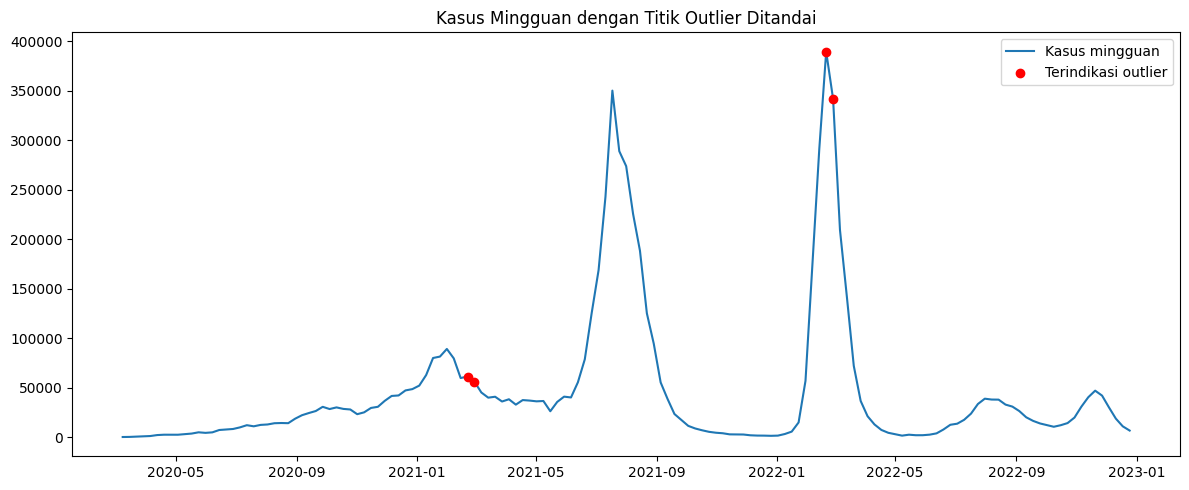

In [9]:
# Visualisasi: tandai minggu-minggu outlier di atas grafik kasus mingguan
plt.figure(figsize=(12, 5))
plt.plot(gabungan.index, gabungan["kasus_baru_mingguan"], label="Kasus mingguan")
plt.scatter(outlier_weeks.index, gabungan.loc[outlier_weeks.index, "kasus_baru_mingguan"],
            color="red", zorder=5, label="Terindikasi outlier")
plt.legend()
plt.title("Kasus Mingguan dengan Titik Outlier Ditandai")
plt.tight_layout()
plt.show()

**Penting:** tidak semua titik yang ditandai di sini otomatis "data salah". Di data pandemi, lonjakan/penurunan tajam sering kali **nyata** — misalnya akibat keterlambatan pelaporan yang menumpuk lalu dirilis sekaligus, hari libur nasional yang menghentikan sementara pelaporan, atau memang gelombang varian baru. Tugas kamu di Data Preparation (Hari 8-14) adalah memutuskan per-kasus: biarkan apa adanya, atau smoothing/koreksi.

---
# BAGIAN C — Hari 7: Konsolidasi & Penutupan Minggu 1

Roadmap generik Hari 7 biasanya berupa mini-project EDA di dataset baru. Karena kamu sudah punya proyek utama sejak Hari 1, Hari 7 versi kamu dipakai untuk **merangkum semua temuan Minggu 1** jadi satu laporan ringkas — supaya Minggu 2 (Data Preparation) punya pijakan yang jelas.

## EDA Summary Report — Minggu 1

**Proyek:** Prediksi Tren Kasus COVID-19 Mingguan Indonesia (nasional, horizon 1 minggu)

**Business Understanding (Hari 1-2)**
- Business objective: bantu masyarakat umum memahami tren kasus naik/turun/stabil
- Baseline naive forecast sudah dihitung di Hari 2 sebagai pembanding model nanti

**Data Understanding (Hari 3-7)**
- Sumber data: covid19.go.id (kasus harian + vaksinasi harian, level nasional)
- Rentang data kasus: 2020-03-02 s/d 2022-12-25 (147 minggu)
- Rentang data vaksinasi: 2021-02-01 s/d 2022-12-25
- Distribusi kasus mingguan menceng kanan (skewed) — wajar untuk data pandemi
- Ditemukan pola musiman/gelombang saat dekomposisi time-series (lihat grafik Hari 6)
- Sejumlah minggu terindikasi outlier melalui analisis residual — dicatat untuk ditangani di Data Preparation

**Keputusan yang sudah diambil**
1. Data vaksinasi sebelum Jan 2021 diisi 0 (bukan dipotong)
2. Fitur vaksinasi final: persentase populasi tervaksin dosis-1 (bukan angka mentah)
3. Outlier residual sudah terdeteksi otomatis — keputusan penanganan menyusul di Hari 8-14

## Refleksi & Keputusan Hari 7

Satu keputusan terakhir sebelum masuk Data Preparation — lihat daftar `outlier_weeks` di atas, lalu pilih:

> Minggu-minggu outlier yang terdeteksi mau ditangani dengan cara: dibiarkan apa adanya (dianggap sinyal asli) / di-smooth dengan rolling average / diselidiki manual satu-satu (cek berita pada tanggal tsb) → diselidiki manual satu-satu (cek berita pada tanggal tsb)

---
### Selanjutnya: Minggu 2 (Hari 8-14) — Data Preparation
Dengan EDA yang sudah solid ini, Minggu 2 akan jauh lebih terarah:
- **Hari 8-9**: Eksekusi keputusan penanganan outlier dari refleksi di atas
- **Hari 10-11**: Feature engineering — buat fitur *lag* (kasus minggu -1, -2, -3) dan rolling average sebagai input model forecasting
- **Hari 12-13**: Scaling (jika perlu) & train-test split time-series (ingat: untuk time-series, split HARUS berurutan berdasarkan waktu, bukan acak — akan dibahas detail di Hari 13)
- **Hari 14**: Mini-project — pipeline data preparation lengkap siap pakai untuk Modeling di Minggu 3